In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Partitioner import getDefaultWineSets
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [3]:
# get shared group split
X_train, X_val, X_test, y_train, y_val, y_test = getDefaultWineSets()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (3897, 12)
Validation shape: (1300, 12)
Test shape: (1300, 12)


In [4]:
# scale using training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


In [5]:
# try one k first
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# validation prediction
y_val_pred = knn.predict(X_val_scaled)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))

Validation accuracy: 0.5546153846153846


In [6]:
#tuning the K using validation set
k_values = range(1, 31)
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_val_pred = knn.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(acc)

best_k = k_values[np.argmax(val_accuracies)]
best_val_acc = max(val_accuracies)

print("Best k:", best_k)
print("Best validation accuracy:", best_val_acc)

Best k: 1
Best validation accuracy: 0.6138461538461538


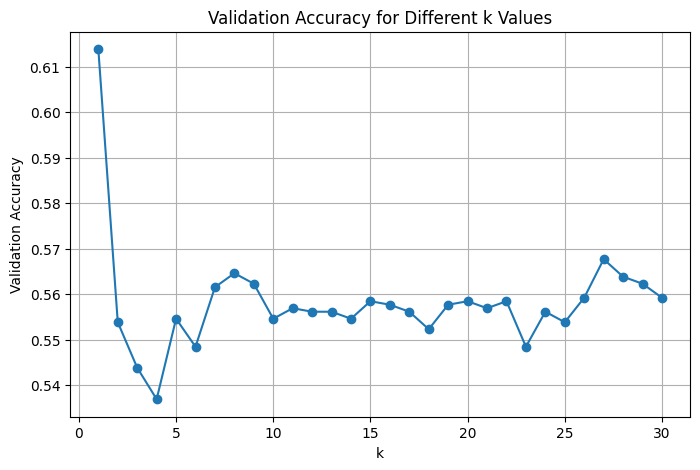

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, val_accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different k Values")
plt.grid(True)
plt.show()

In [8]:
# train final model with best k
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

y_test_pred = final_knn.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Test accuracy: 0.5676923076923077


In [9]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

y_test_pred = final_knn.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Test accuracy: 0.5676923076923077


In [10]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.12      0.12      0.12        40
           5       0.61      0.64      0.63       419
           6       0.58      0.59      0.58       564
           7       0.57      0.52      0.54       231
           8       0.38      0.36      0.37        39
           9       0.00      0.00      0.00         1

    accuracy                           0.57      1300
   macro avg       0.32      0.32      0.32      1300
weighted avg       0.57      0.57      0.57      1300

Confusion Matrix:
[[  0   2   2   2   0   0   0]
 [  0   5  24  10   1   0   0]
 [  0  16 269 122   8   4   0]
 [  3  14 131 330  74  12   0]
 [  1   3  11  90 120   6   0]
 [  0   0   2  16   7  14   0]
 [  0   0   0   0   0   1   0]]


/Users/allysonlopez/UCI/CS 178/Wine project/178-Group-Project/178-Group-Project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/allysonlopez/UCI/CS 178/Wine project/178-Group-Project/178-Group-Project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/allysonlopez/UCI/CS 178/Wine project/178-Group-Project/178-Group-Project/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set 

In [ ]:
#first run
X_train, X_val, X_test, y_train, y_val, y_test = getDefaultWineSets()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

k_values = range(1, 31)
val_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    val_accuracies.append(accuracy_score(y_val, preds))

best_k = k_values[val_accuracies.index(max(val_accuracies))]
print("Best k:", best_k)

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
test_preds = final_model.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, test_preds))

Best k: 1
Test accuracy: 0.5676923076923077


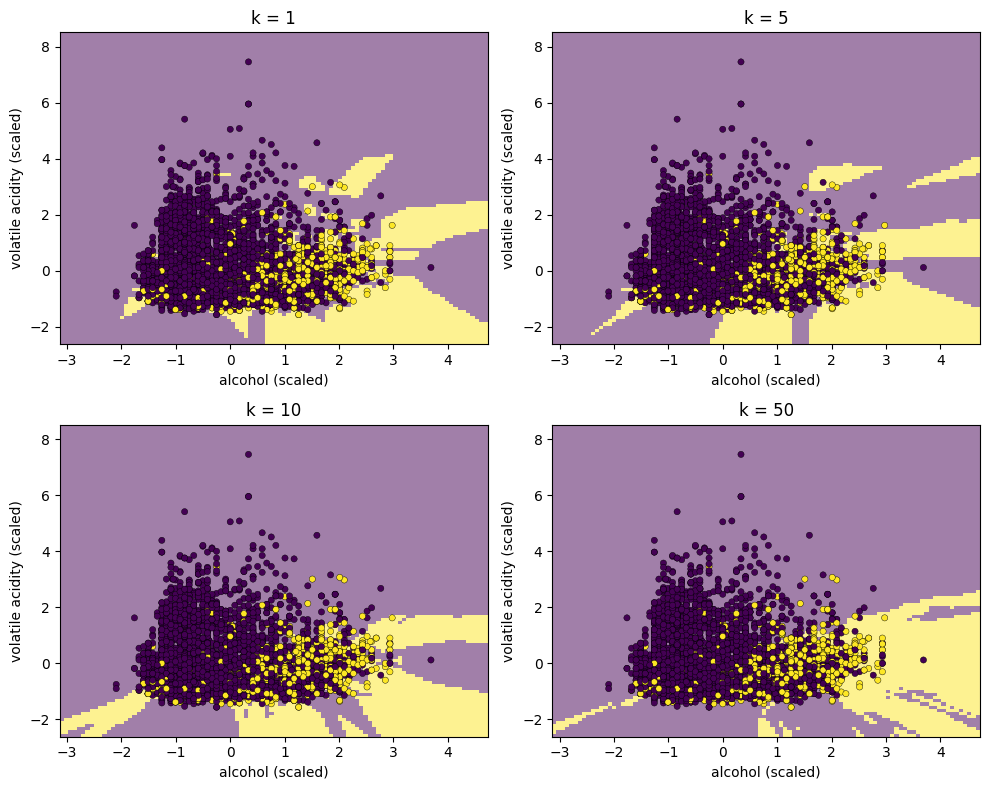

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay

# load data
red = pd.read_csv("wine+quality/winequality-red.csv", sep=";")
white = pd.read_csv("wine+quality/winequality-white.csv", sep=";")

# add wine type
red["wine_type"] = 0
white["wine_type"] = 1

# combine
wine = pd.concat([red, white], ignore_index=True)

# binary target
wine["good_quality"] = (wine["quality"] >= 7).astype(int)

# choose ONLY TWO features for plotting
X = wine[["alcohol", "volatile acidity"]]
y = wine["good_quality"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# plotting settings
plot_kwargs = {
    "cmap": "viridis",
    "response_method": "predict",
    "plot_method": "pcolormesh",
    "shading": "auto",
    "alpha": 0.5,
    "grid_resolution": 100
}

# create subplots
figure, axes = plt.subplots(2, 2, figsize=(10, 8))

k_values = [1, 5, 10, 50]

for ax, k in zip(axes.ravel(), k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    DecisionBoundaryDisplay.from_estimator(
        knn,
        X_train_scaled,
        ax=ax,
        **plot_kwargs
    )

    ax.scatter(
        X_train_scaled[:, 0],
        X_train_scaled[:, 1],
        c=y_train,
        s=20,
        edgecolors="k",
        linewidths=0.3
    )

    ax.set_title(f"k = {k}")
    ax.set_xlabel("alcohol (scaled)")
    ax.set_ylabel("volatile acidity (scaled)")

plt.tight_layout()
plt.show()